In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load the CSV and clean data.
raw = pd.read_csv("CFM 301 A1 Data.csv")
raw["MthCalDt"] = pd.to_datetime(raw["MthCalDt"])

tickers = ["AMZN", "CLS", "ENB", "MFC", "MSFT", "RY", "SHOP", "SU"]

cleaned = raw[raw["Ticker"].isin(tickers)].copy()
cleaned = cleaned.sort_values(["Ticker", "MthCalDt"])
cleaned = cleaned.groupby(["Ticker", "MthCalDt"], as_index=False)["MthPrc"].mean()
cleaned["Return"] = cleaned.groupby("Ticker")["MthPrc"].pct_change()

returns = cleaned.pivot(index="MthCalDt", columns="Ticker", values="Return").sort_index()

print("Cleaned price data:")
print(cleaned.head())
print()
print("Monthly return table:")
print(returns.head())


Cleaned price data:
  Ticker   MthCalDt      MthPrc    Return
0   AMZN 2020-01-31 2008.720000       NaN
1   AMZN 2020-02-28 1883.750000 -0.062214
2   AMZN 2020-03-31 1949.720000  0.035021
3   AMZN 2020-04-30 2474.000000  0.268900
4   AMZN 2020-05-29 2442.370000 -0.012785

Monthly return table:
Ticker          AMZN       CLS       ENB       MFC      MSFT        RY  \
MthCalDt                                                                 
2020-01-31       NaN       NaN       NaN       NaN       NaN       NaN   
2020-02-28 -0.062214 -0.300885 -0.079666 -0.135080 -0.048288 -0.056864   
2020-03-31  0.035021 -0.446203 -0.222816 -0.255344 -0.026542 -0.173493   
2020-04-30  0.268900  0.780000  0.054658  0.004785  0.136326  0.000650   
2020-05-29 -0.012785  0.088283  0.057692 -0.015079  0.022543  0.052931   

Ticker          SHOP        SU  
MthCalDt                        
2020-01-31       NaN       NaN  
2020-02-28 -0.005047 -0.097744  
2020-03-31 -0.100106 -0.427536  
2020-04-30  0.516538 

In [55]:
# Build a CAD Tech portfolio, and US Tech portfolio, and compute the efficient frontier.
portfolio_a = ["AMZN", "ENB", "MFC", "MSFT", "RY", "SU"]
portfolio_b = ["CLS", "ENB", "MFC", "RY", "SHOP", "SU"]
risk_aversion = 3


def efficient_frontier(portfolio_tickers, n_points=80):
    frame = returns[portfolio_tickers].dropna(how="any").copy()
    mean_returns = frame.mean()
    cov_matrix = frame.cov()
    n_assets = len(portfolio_tickers)
    bounds = [(0, 1)] * n_assets
    start = np.repeat(1 / n_assets, n_assets)
    targets = np.linspace(mean_returns.min(), mean_returns.max(), n_points)

    frontier_returns = []
    frontier_variances = []
    frontier_weights = []

    for target in targets:
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, target=target: w @ mean_returns - target},
        ]

        result = minimize(
            lambda w: w @ cov_matrix @ w,
            start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
        )

        if result.success:
            weights = result.x
            frontier_weights.append(weights)
            frontier_returns.append(weights @ mean_returns)
            frontier_variances.append(weights @ cov_matrix @ weights)

    frontier_returns = np.array(frontier_returns)
    frontier_variances = np.array(frontier_variances)
    utility = frontier_returns - 0.5 * risk_aversion * frontier_variances
    best_index = int(np.argmax(utility))

    min_var_result = minimize(
        lambda w: w @ cov_matrix @ w,
        start,
        method="SLSQP",
        bounds=bounds,
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
    )

    return {
        "frame": frame,
        "mean_returns": mean_returns,
        "cov_matrix": cov_matrix,
        "frontier_returns": frontier_returns,
        "frontier_variances": frontier_variances,
        "frontier_weights": frontier_weights,
        "best_weights": pd.Series(frontier_weights[best_index], index=portfolio_tickers),
        "best_return": frontier_returns[best_index],
        "best_variance": frontier_variances[best_index],
        "best_utility": utility[best_index],
        "min_var_weights": pd.Series(min_var_result.x, index=portfolio_tickers),
        "min_var_return": float(min_var_result.x @ mean_returns),
        "min_var_variance": float(min_var_result.x @ cov_matrix @ min_var_result.x),
    }


analysis_a = efficient_frontier(portfolio_a)
analysis_b = efficient_frontier(portfolio_b)

analysis = {
    "AMZN / ENB / MFC / MSFT / RY / SU": analysis_a,
    "CLS / ENB / MFC / RY / SHOP / SU": analysis_b,
}

for name, result in analysis.items():
    print(name)
    print("Mean returns:")
    print(result["mean_returns"].round(6))
    print("Covariance matrix:")
    print(result["cov_matrix"].round(6))
    print("Variance:")
    print(pd.Series(np.diag(result["cov_matrix"]), index=result["cov_matrix"].index).round(6))
    print()


AMZN / ENB / MFC / MSFT / RY / SU
Mean returns:
Ticker
AMZN   0.004058
ENB    0.004214
MFC    0.011516
MSFT   0.016823
RY     0.012954
SU     0.011797
dtype: float64
Covariance matrix:
Ticker     AMZN      ENB      MFC     MSFT       RY       SU
Ticker                                                      
AMZN   0.021605 0.002108 0.002517 0.004825 0.001901 0.001920
ENB    0.002108 0.003762 0.003007 0.001204 0.002833 0.004499
MFC    0.002517 0.003007 0.005452 0.001594 0.003740 0.004949
MSFT   0.004825 0.001204 0.001594 0.004185 0.001170 0.000904
RY     0.001901 0.002833 0.003740 0.001170 0.004193 0.003807
SU     0.001920 0.004499 0.004949 0.000904 0.003807 0.012718
Variance:
Ticker
AMZN   0.021605
ENB    0.003762
MFC    0.005452
MSFT   0.004185
RY     0.004193
SU     0.012718
dtype: float64

CLS / ENB / MFC / RY / SHOP / SU
Mean returns:
Ticker
CLS    0.066877
ENB    0.004214
MFC    0.011516
RY     0.012954
SHOP   0.020952
SU     0.011797
dtype: float64
Covariance matrix:
Ticker      CL

In [52]:
# Choose the efficient portfolio with risk aversion 3.
selected_name, selected_result = max(analysis.items(), key=lambda item: item[1]["best_utility"])
selected_weights = selected_result["best_weights"].sort_values(ascending=False)

print("Selected efficient portfolio:", selected_name)
print("Criterion: maximize U = E[R] - 0.5*A*Var(R) with A = 3.")
print("This is the point where the risk-aversion-3 utility curve is tangent to the efficient frontier.")
print()
print("Expected return:", round(selected_result["best_return"], 6))
print("Variance:", round(selected_result["best_variance"], 6))
print("Volatility:", round(np.sqrt(selected_result["best_variance"]), 6))
print()
print("Efficient portfolio weights (%):")
print((selected_weights * 100).round(2).to_frame(name="WeightPct"))


Selected efficient portfolio: CLS / ENB / MFC / RY / SHOP / SU
Criterion: maximize U = E[R] - 0.5*A*Var(R) with A = 3.
This is the point where the risk-aversion-3 utility curve is tangent to the efficient frontier.

Expected return: 0.043081
Variance: 0.01405
Volatility: 0.118533

Efficient portfolio weights (%):
      WeightPct
CLS   55.870000
RY    44.130000
ENB    0.000000
MFC    0.000000
SHOP   0.000000
SU     0.000000


In [53]:
# Print the constraints used in the analysis.
print("Constraints used:")
print("1. Long-only weights: each weight is constrained to lie between 0 and 1.")
print("2. Fully invested: the weights must sum to 1.")
print("3. Duplicate ticker-date prices are averaged before returns are calculated.")
print()


Constraints used:
1. Long-only weights: each weight is constrained to lie between 0 and 1.
2. Fully invested: the weights must sum to 1.
3. Duplicate ticker-date prices are averaged before returns are calculated.



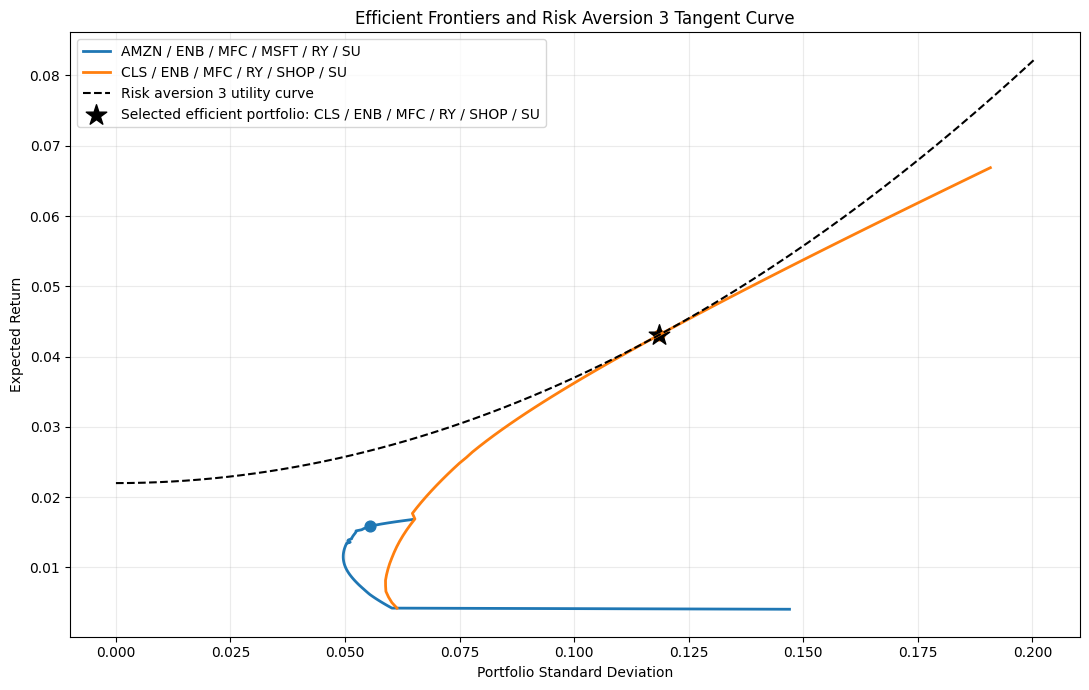

In [54]:
# Plot both efficient frontiers and the risk aversion 3 utility curve.
plt.figure(figsize=(11, 7))

max_stdev = max(np.sqrt(result["frontier_variances"]).max() for result in analysis.values())
x_values = np.linspace(0, max_stdev * 1.05, 200)
selected_utility = selected_result["best_utility"]
tangent_curve = selected_utility + 0.5 * risk_aversion * x_values**2

for name, result in analysis.items():
    frontier_stdev = np.sqrt(result["frontier_variances"])
    plt.plot(
        frontier_stdev,
        result["frontier_returns"],
        linewidth=2,
        label=name,
    )
    plt.scatter(
        np.sqrt(result["best_variance"]),
        result["best_return"],
        s=60,
    )

plt.plot(x_values, tangent_curve, "k--", label="Risk aversion 3 utility curve")
plt.scatter(
    np.sqrt(selected_result["best_variance"]),
    selected_result["best_return"],
    marker="*",
    s=240,
    color="black",
    label=f"Selected efficient portfolio: {selected_name}",
)

plt.xlabel("Portfolio Standard Deviation")
plt.ylabel("Expected Return")
plt.title("Efficient Frontiers and Risk Aversion 3 Tangent Curve")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()